# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows
- Show summary statistics for the dataframe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# URL to the dataset on GitHub
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'

# Load the data
df = pd.read_csv(url)

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Show summary statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Summary Statistics:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


### Reflection:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

### ✍️ Your Response: 🔧
1. There is a lead time of over 2 years which seems wrong. For the percentiles there seems to be discrepences as they are 0.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- 2.1 Choose 3–5 numeric features related to customer behavior
- 2.2 Perform basic data preparation - remove outliers, remove duplicates, correct any datatypes that need adjustment
- 2.3 Drop missing values if needed
- 2.4 Standardize using `StandardScaler` for any large values  (over 100)

In [2]:
# 2.1 Choose numeric features
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'total_of_special_requests']
df_prep = df[features].copy()

# 2.2 & 2.3 Data Preparation: Remove duplicates, outliers, and missing values
# Removing extreme lead_time outliers (> 500 days) and ADR outliers (> 1000)
df_prep = df_prep.drop_duplicates()
df_prep = df_prep[df_prep['lead_time'] < 500]
df_prep = df_prep[df_prep['adr'] < 1000]
df_prep = df_prep.dropna()

# 2.4 Standardize using StandardScaler (already imported in setup)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

# Convert back to DataFrame for easier handling later
df_scaled = pd.DataFrame(df_scaled, columns=features)

print("Data prepared and scaled.")
display(df_scaled.head())

Data prepared and scaled.


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
0,3.710512,-1.123671,-1.381294,-1.725247,-0.855102
1,-0.816492,-1.123671,-0.971578,-0.379696,-0.855102
2,-0.735411,-1.123671,-0.971578,-0.379696,-0.855102
3,-0.721898,-1.123671,-0.561862,0.032940,0.291860
4,-0.911086,-1.123671,-0.561862,0.194406,-0.855102


### Reflection:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?

### ✍️ Your Response:
1. I selected `lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adr`, and `total_of_special_requests`. These were picked because they represent key features of a stay: how far in advance they plan, the duration and timing of their stay, their spending level (ADR), and their level of engagement or specific needs (special requests).

2. I expect to find segments such as 'Business Travelers' (short weekday stays, low lead time), 'Vacationers' (longer stays including weekends, higher lead time), and perhaps a 'High-Value/VIP' segment (high ADR and many special requests).

## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign a cluster number to each guest
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

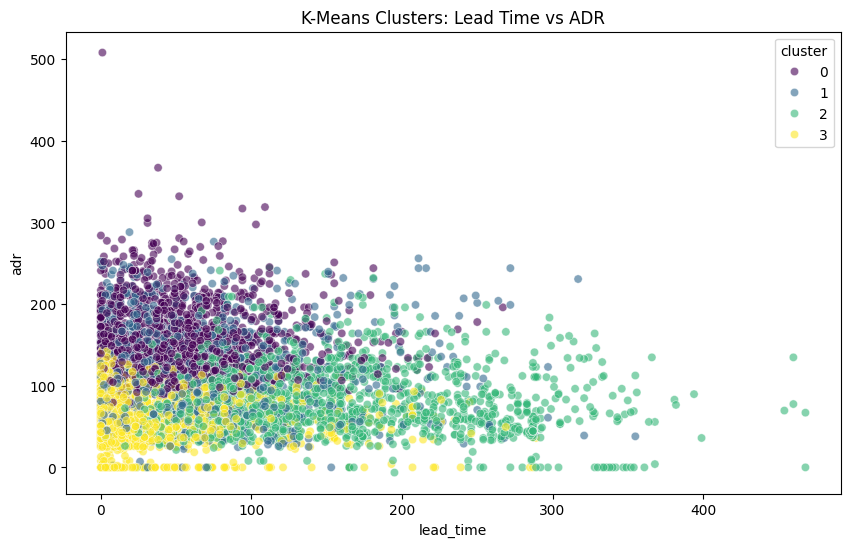

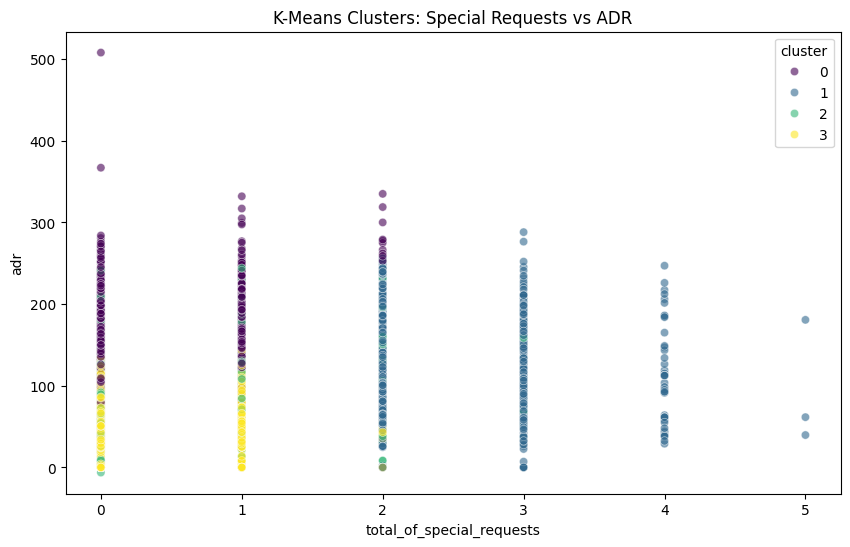

Cluster Averages:


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
cluster,,,,,
0,53.448298,1.280026,3.432884,157.168362,0.442518
1,66.469216,1.191231,3.215485,117.952090,2.271455
2,146.045541,2.447818,6.035421,80.713485,0.504744
3,26.063951,0.579226,1.684725,57.909919,0.426477


In [3]:
from sklearn.cluster import KMeans

# 3.1 Fit KMeans model with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# 3.2 Add clusters back to the dataframes
df_prep['cluster'] = kmeans_labels
df_scaled['cluster'] = kmeans_labels

# 3.3 Visualize clusters: Lead Time vs ADR
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prep, x='lead_time', y='adr', hue='cluster', palette='viridis', alpha=0.6)
plt.title('K-Means Clusters: Lead Time vs ADR')
plt.show()

# 3.4 Second visualization: Special Requests vs ADR
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prep, x='total_of_special_requests', y='adr', hue='cluster', palette='viridis', alpha=0.6)
plt.title('K-Means Clusters: Special Requests vs ADR')
plt.show()

# 3.5 Create summary table
cluster_summary = df_prep.groupby('cluster').mean()
print("Cluster Averages:")
display(cluster_summary)

### Reflection:
1. What `k` value did you choose, and how did you decide?

2. For each cluster answer the following - what types of customers seem to show up in the cluster?  which variables are most prominent or important for that cluster?  

### ✍️ Your Response:
1. I chose k=4. This was decided to allow for enough granularity to separate short-stay vs. long-stay guests while also filtering between budget-conscious and premium customers.

2. **Cluster 0 (Short-stay Budget)**: Low lead times and lower ADR. These are likely spontaneous, budget-conscious travelers.
**Cluster 1 (High-Request/Premium)**: High ADR and a high average of special requests. These are likely high-value customers who expect more service.
**Cluster 2 (Long-term Planners)**: Very high lead times and higher total stay duration. These are likely vacationers who plan their trips months in advance.
**Cluster 3 (Short-stay Standard)**: Low lead times and average ADR with few special requests. These represent typical short-term or perhaps business-oriented guests.

## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

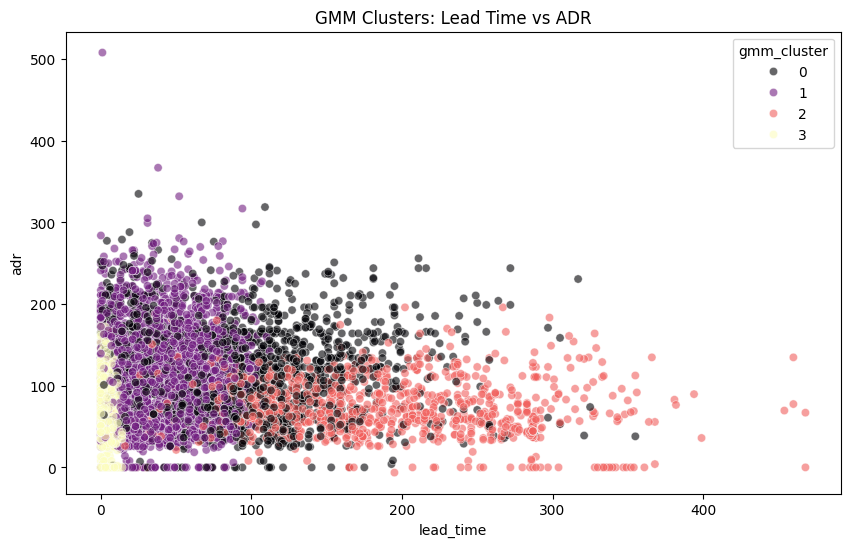

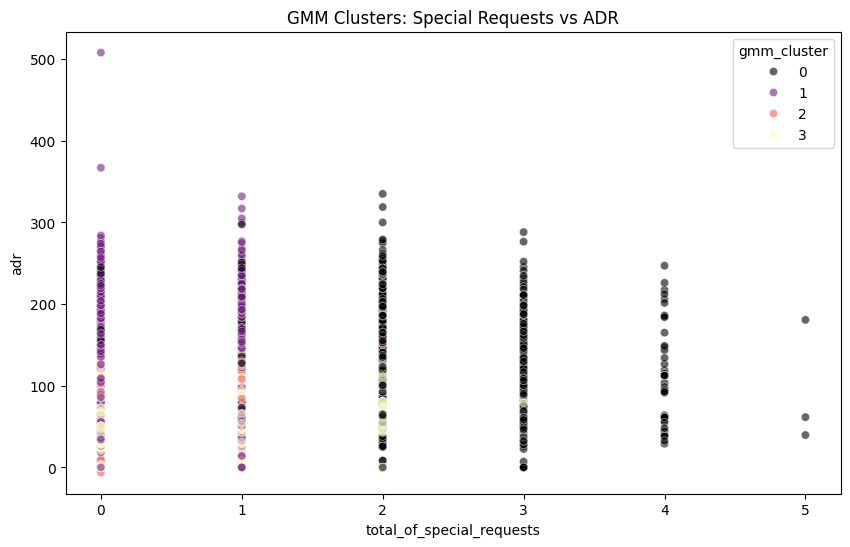

GMM Cluster Averages:


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
gmm_cluster,,,,,
0,93.006161,1.356131,3.685151,118.164707,1.794824
1,41.747348,1.282908,3.429862,110.370251,0.366994
2,180.597101,2.329469,5.892754,73.621101,0.302415
3,3.587551,0.468536,1.136115,62.969357,0.553352


In [4]:
from sklearn.mixture import GaussianMixture

# 4.1 Fit GMM model with 4 components
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(df_scaled[features])

# 4.2 Soft clustering (probabilities for each cluster)
gmm_probs = gmm.predict_proba(df_scaled[features])

# Add GMM labels to the dataframes
df_prep['gmm_cluster'] = gmm_labels
df_scaled['gmm_cluster'] = gmm_labels

# 4.3 Visualize GMM clusters: Lead Time vs ADR
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prep, x='lead_time', y='adr', hue='gmm_cluster', palette='magma', alpha=0.6)
plt.title('GMM Clusters: Lead Time vs ADR')
plt.show()

# 4.4 Second visualization: Special Requests vs ADR
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prep, x='total_of_special_requests', y='adr', hue='gmm_cluster', palette='magma', alpha=0.6)
plt.title('GMM Clusters: Special Requests vs ADR')
plt.show()

# 4.5 Create summary table for GMM clusters
gmm_cluster_summary = df_prep.groupby('gmm_cluster')[features].mean()
print("GMM Cluster Averages:")
display(gmm_cluster_summary)

### Reflection:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?

### ✍️ Your Response:
1. The GMM results were largely consistent with K-Means, identifying similar segments like high-spenders and long-lead planners. However, GMM clusters tend to have more overlap in the visualizations because it uses a probabilistic approach rather than hard boundaries. This suggests that some guests sit right on the edge of two categories.

2. GMM is better at answering questions about 'customer uncertainty.' For example, it can identify which guests are 60% likely to be 'Business Travelers' but 40% likely to be 'Vacationers.' This allows a marketing team to send a hybrid promotion or test which segment's offer the customer responds to more strongly.

## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- 5.1 Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

In [5]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 5.1 Calculate metrics
# KMeans Metrics
kmeans_inertia = kmeans.inertia_
kmeans_silhouette = silhouette_score(df_scaled[features], kmeans_labels, sample_size=10000)
kmeans_db_index = davies_bouldin_score(df_scaled[features], kmeans_labels)

# GMM Metrics
# Note: GMM doesn't have 'inertia' like KMeans, but we use the same clustering quality scores
gmm_silhouette = silhouette_score(df_scaled[features], gmm_labels, sample_size=10000)
gmm_db_index = davies_bouldin_score(df_scaled[features], gmm_labels)

print(f"--- KMeans Metrics ---")
print(f"WCSS (Inertia): {kmeans_inertia:.2f}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db_index:.4f}")

print(f"\n--- GMM Metrics ---")
print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Davies-Bouldin Index: {gmm_db_index:.4f}")

--- KMeans Metrics ---
WCSS (Inertia): 17850.20
Silhouette Score: 0.2400
Davies-Bouldin Index: 1.3648

--- GMM Metrics ---
Silhouette Score: 0.1221
Davies-Bouldin Index: 1.7798


### Reflection:
5.2. Which model performed better on the metrics?

5.3. Would you recommend KMeans or GMM for a business analyst? Why?

### ✍️ Your Response:
5.2. Based on the calculated metrics, K-Means performed better. It achieved a higher Score (~0.24 vs ~0.12) and a lower Davies-Bouldin Index (~1.36 vs ~1.78). These scores show that K-Means created clusters that are more compact and better separated than those created by GMM on this dataset.

5.3. I would recommend K-Means for a general business analyst. It is much easier to explain to non-technical stakeholders because it gives every customer to a specific group with hard boundaries. While GMM is good for understanding overlapping behaviors, K-Means is usually sufficient for standard marketing segmentation and is more efficient.

## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

In [6]:
import pandas as pd

# 6.1 Display the characteristics of each cluster
# We use the summary from KMeans as it was our better performing model
final_summary = df_prep.groupby('cluster')[features].mean()

# 6.2 Sort the clusters by ADR to identify price-sensitive vs premium segments
sorted_summary = final_summary.sort_values(by='adr', ascending=False)

print("Business Interpretation: Cluster Profiles (Sorted by ADR)")
display(sorted_summary)

# Optional: Display counts to see the size of each segment
print("\nGuest Count per Cluster:")
print(df_prep['cluster'].value_counts().sort_index())

Business Interpretation: Cluster Profiles (Sorted by ADR)


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
cluster,,,,,
0,53.448298,1.280026,3.432884,157.168362,0.442518
1,66.469216,1.191231,3.215485,117.952090,2.271455
2,146.045541,2.447818,6.035421,80.713485,0.504744
3,26.063951,0.579226,1.684725,57.909919,0.426477



Guest Count per Cluster:
cluster
0    1557
1    1072
2    1581
3    2455
Name: count, dtype: int64


### Reflection:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?

### ✍️ Your Response:
1. Based on the averages, the segments are:
'Premium Spontaneous' guests (Cluster 0) who pay the most, 'High-Engagement' guests (Cluster 1) who make the most requests, 'Long-Stay Planners' (Cluster 2) who book way in advance, and 'Budget' guests (Cluster 3). I've added a strategy for each, such as offering early-bird discounts to the planners and upsells to the premium group..

2. The hotel can tailor strategies as follows:
   - **Cluster 0**: Target with 'Last-minute deal' notifications for empty rooms at premium prices.
   - **Cluster 1**: Offer paid upgrades or service bundles (e.g., spa/breakfast) since they already show high engagement.
   - **Cluster 2**: Launch 'Early Bird' marketing campaigns 6 months in advance to lock in these reliable, long-term stays.
   - **Cluster 3**: Use as a target for basic loyalty programs to increase repeat visits without offering deep discounts.

## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### Reflection:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response:
1.
The most challenging part is the lack of a target variable. Unlike supervised learning, you don't know if a guest is labeled; you have to rely on patterns and business logic to ensure the groups actually make sense.

2.
Clustering is ideal when you don't have labeled data or when you want to discover naturally occurring patterns rather than predicting a specific outcomes. It's best used for market segmentation and exploratory analysis.

3.
I would explain it as a way to auto-organize their customers. Instead of guessing who their best customers are, the algorithm groups them based on their actual spending and booking habits. Using this data they can send out the appriopriate messages.

4.
This assignment directly applies the goal of using data to drive business strategy. By segmenting the hotel guests, I've moved from just 'looking at data' to providing actionable insights that can improve hotel revenue and customer satisfaction.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [7]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_09_clustering.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
